In [3]:
# Original
# import graphlab
# sales = graphlab.SFrame('home_data.gl/')

# Data: https://www.kaggle.com/datasets/harlfoxem/housesalesprediction?resource=download


In [1]:
import pandas as pd
sales = pd.read_csv('kc_house_data.csv')

In [2]:
sales

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [ ]:
# graphlab.canvas.set_target('ipynb')        # Jupyter上に表示する設定
# sales.show(view="Scatter Plot", x="sqft_living", y="price")  # 散布図を表示


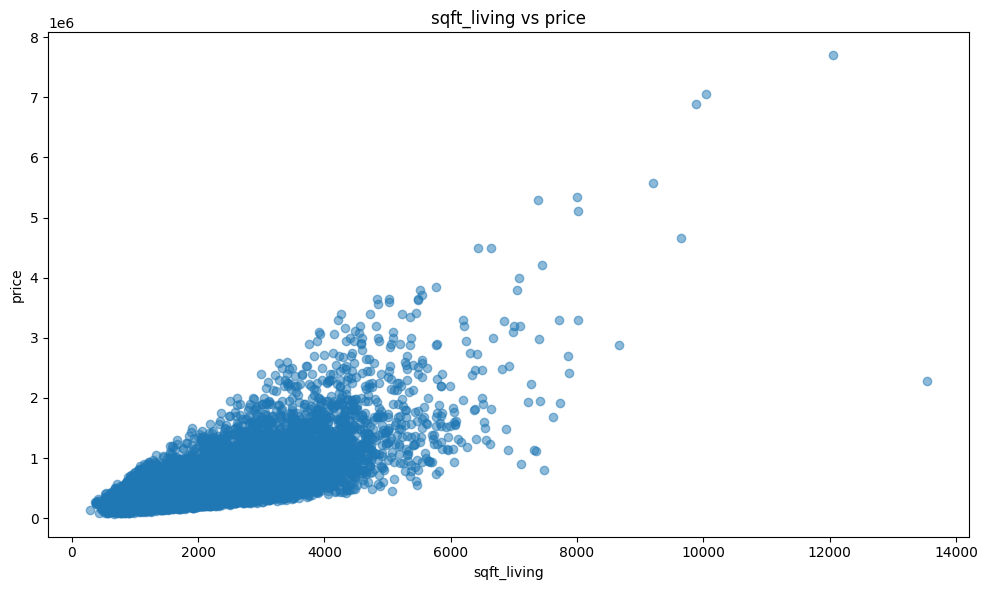

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(sales['sqft_living'], sales['price'], alpha=0.5)

plt.xlabel('sqft_living')
plt.ylabel('price')
plt.title('sqft_living vs price')

plt.tight_layout()
plt.show()

In [ ]:
# 広さだけで回帰分析
# train_data, test_data = sales.random_split(.8, seed=0)
# 80%を訓練データ、20%をテストデータに分割
# seed=0 で再現性を確保

In [16]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(sales, test_size=0.2, random_state=0)

In [ ]:
# sqft_model = graphlab.linear_regression.create(
#     train_data, target='price', features=['sqft_living']
# )
# # sqft_living を使って price を予測する線形回帰モデルを作成

In [17]:
from sklearn.linear_model import LinearRegression

# モデルの作成と学習
sqft_model = LinearRegression()
sqft_model.fit(train_data[['sqft_living']], train_data['price'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# print test_data['price'].mean()          # テストデータの平均価格
# print sqft_model.evaluate(test_data)     # max_error と rmse を計算

In [18]:
import numpy as np
from sklearn.metrics import mean_squared_error, max_error

# 平均価格
print(test_data['price'].mean())

# 予測
predictions = sqft_model.predict(test_data[['sqft_living']])

# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(test_data['price'], predictions))

# Max Error
max_err = max_error(test_data['price'], predictions)

print({'max_error': max_err, 'rmse': rmse})

529242.6123062688
{'max_error': 3005746.3377638366, 'rmse': np.float64(248879.06124185043)}


In [ ]:
# import matplotlib.pyplot as plt
# %matplotlib inline  # Jupyter上にグラフをインライン表示する設定

# plt.plot(test_data['sqft_living'], test_data['price'], '.',        # 実際の値を点で表示
#          test_data['sqft_living'], sqft_model.predict(test_data), '-')  # 予測値を線で表示

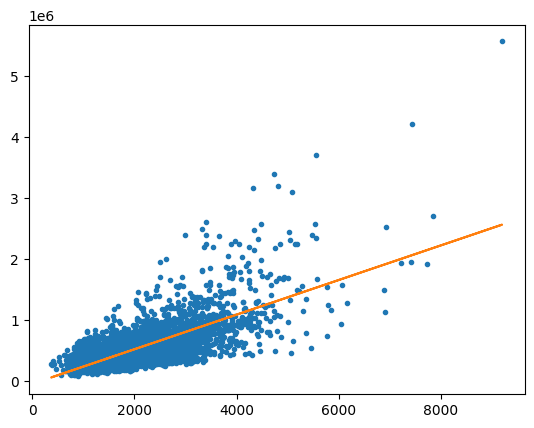

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(test_data['sqft_living'], test_data['price'], '.',
         test_data['sqft_living'], sqft_model.predict(test_data[['sqft_living']]), '-')

In [12]:
sqft_model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# sqft_model.get('coefficients')
# # モデルの切片と係数をテーブル形式で表示

In [8]:
import pandas as pd

coefficients = pd.DataFrame({
    'name': ['(intercept)', 'sqft_living'],
    'index': [None, None],
    'value': [sqft_model.intercept_, sqft_model.coef_[0]]
})

print(coefficients)

          name index         value
0  (intercept)  None -48257.063591
1  sqft_living  None    283.968557


In [9]:
print('切片 (intercept):', sqft_model.intercept_)
print('係数 (sqft_living):', sqft_model.coef_[0])

切片 (intercept): -48257.063591027516
係数 (sqft_living): 283.9685571551295


In [ ]:
# my_features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'zipcode']
# sales[my_features].show()  # 指定した列をGUI形式で表示

In [19]:
my_features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'zipcode']

# Jupyter Notebook上での表示
sales[my_features].head()




,bedrooms,bathrooms,sqft_living,sqft_lot,floors,zipcode
0,3,1.00,1180,5650,1.0,98178
1,3,2.25,2570,7242,2.0,98125
2,2,1.00,770,10000,1.0,98028
3,4,3.00,1960,5000,1.0,98136
4,3,2.00,1680,8080,1.0,98074


In [20]:
# 先頭5行
sales[my_features].head()

# 先頭10行
sales[my_features].head(10)

# 基本統計量も確認したい場合
sales[my_features].describe()

# 全データ件数と列情報
sales[my_features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   bedrooms     21613 non-null  int64  
 1   bathrooms    21613 non-null  float64
 2   sqft_living  21613 non-null  int64  
 3   sqft_lot     21613 non-null  int64  
 4   floors       21613 non-null  float64
 5   zipcode      21613 non-null  int64  
dtypes: float64(2), int64(4)
memory usage: 1013.2 KB


In [21]:
from IPython.display import display

display(sales[my_features].head())
display(sales[my_features].describe())


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,zipcode
0,3,1.00,1180,5650,1.0,98178
1,3,2.25,2570,7242,2.0,98125
2,2,1.00,770,10000,1.0,98028
3,4,3.00,1960,5000,1.0,98136
4,3,2.00,1680,8080,1.0,98074


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,zipcode
count,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000
mean,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,98077.939805
std,0.930062,0.770163,918.440897,4.142051e+04,0.539989,53.505026
min,0.000000,0.000000,290.000000,5.200000e+02,1.000000,98001.000000
25%,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,98033.000000
50%,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,98065.000000
75%,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,98118.000000
max,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,98199.000000


In [ ]:
# sales.show(view='BoxWhisker Plot', x='zipcode', y='price')
# # zipcodeごとにpriceの箱ひげ図を表示

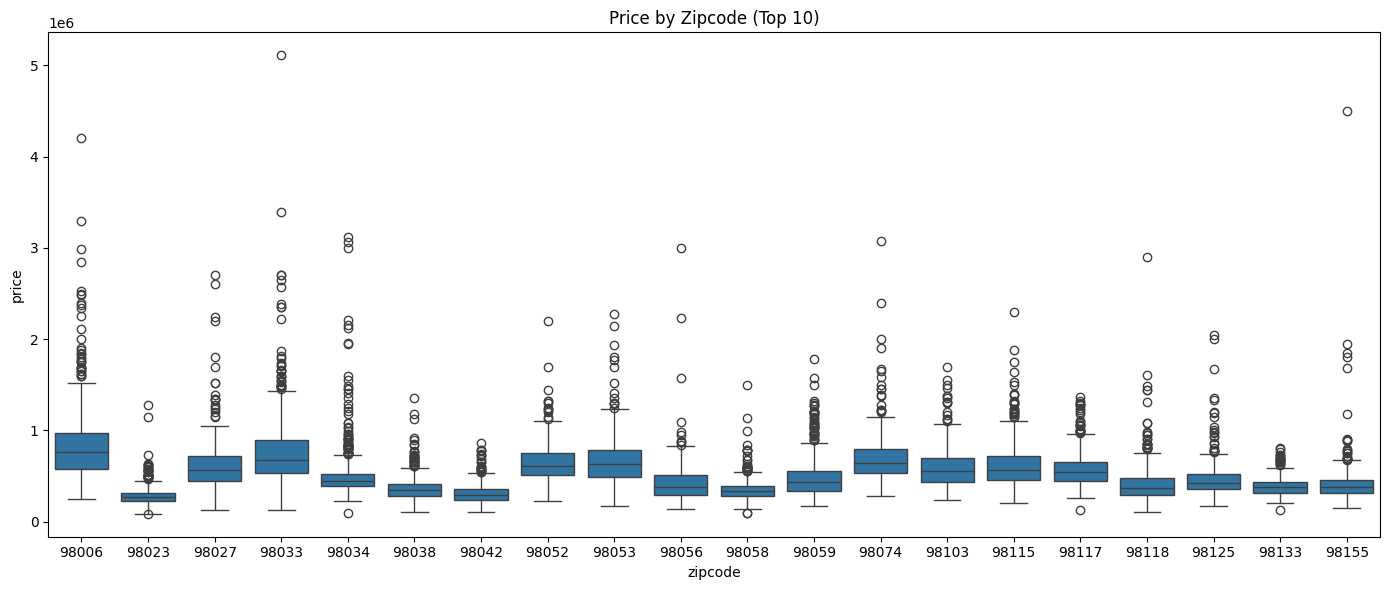

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 件数の多い上位10 zipcodeに絞る
top_zipcodes = sales['zipcode'].value_counts().head(20).index
filtered = sales[sales['zipcode'].isin(top_zipcodes)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=filtered, x='zipcode', y='price')

plt.title('Price by Zipcode (Top 10)')
plt.tight_layout()
plt.show()

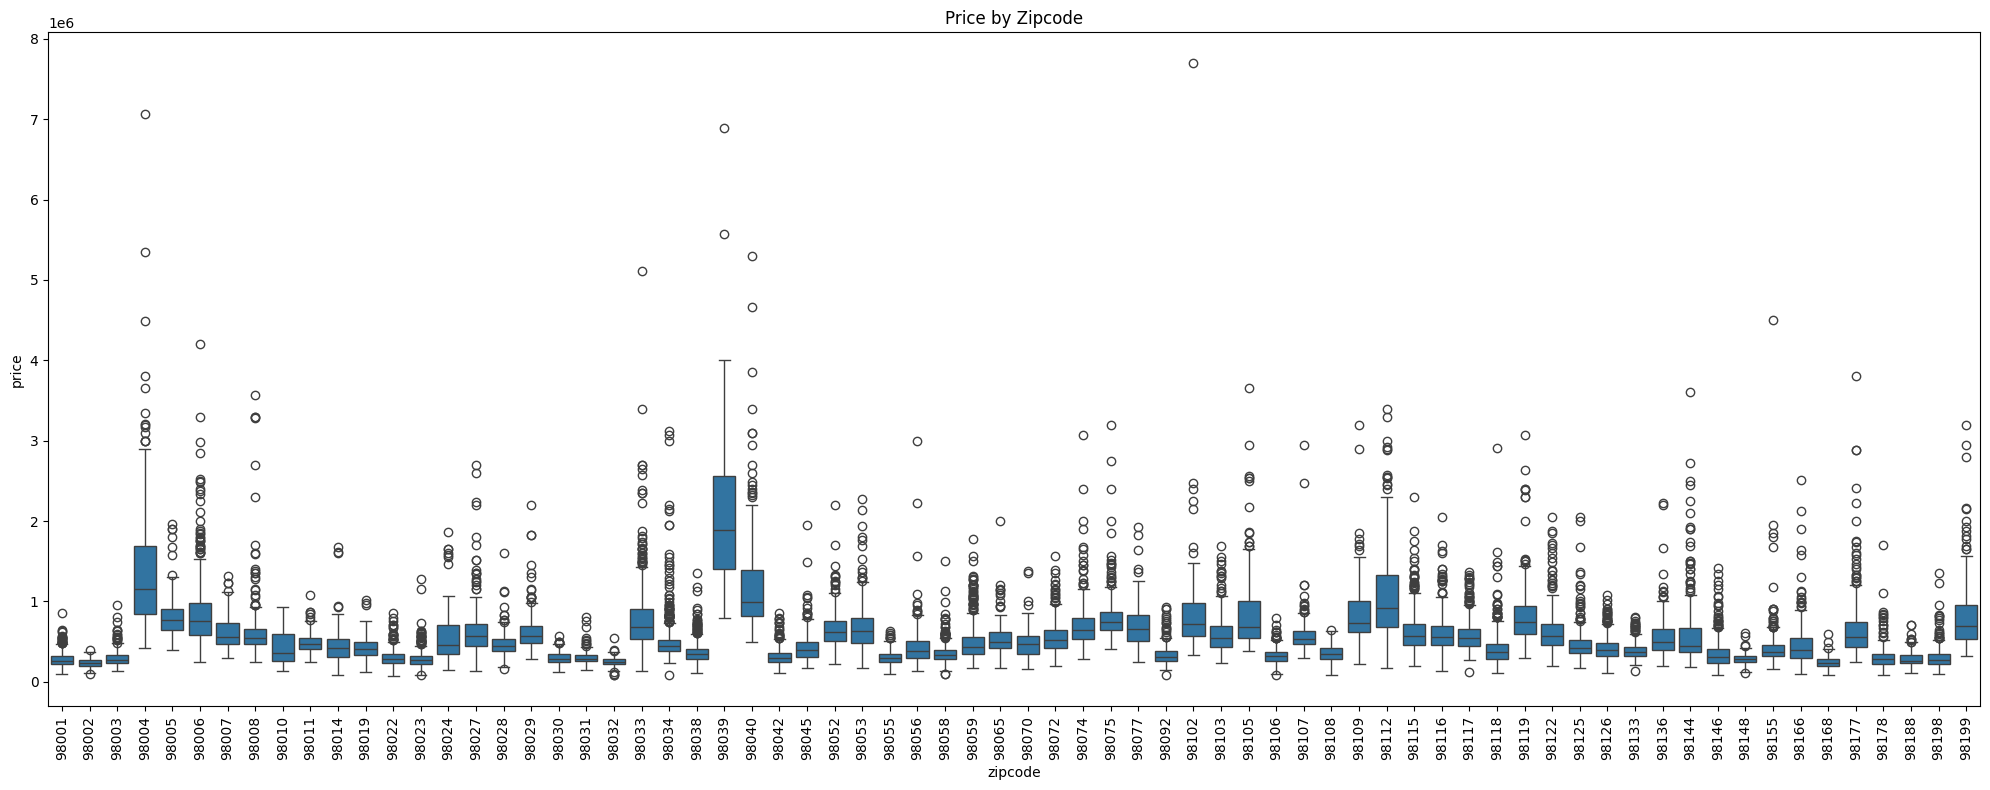

In [23]:
# 全件

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 8))
sns.boxplot(data=sales, x='zipcode', y='price')

plt.xticks(rotation=90)  # zipcode ラベルを縦に
plt.title('Price by Zipcode')
plt.tight_layout()
plt.show()

In [23]:
# zipcode: 98039 だけ抽出
display(sales[sales['zipcode'] == 98039])

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
2974,3625049014,20140829T000000,2950000.0,4,3.50,4860,23885,2.0,0,0,...,12,4860,0,1996,0,98039,47.6172,-122.230,3580,16054
3761,2540700110,20150212T000000,1905000.0,4,3.50,4210,18564,2.0,0,0,...,11,4210,0,2001,0,98039,47.6206,-122.225,3520,18564
4077,3262300940,20141107T000000,875000.0,3,1.00,1220,8119,1.0,0,0,...,7,1220,0,1955,0,98039,47.6328,-122.236,1910,8119
4078,3262300940,20150210T000000,940000.0,3,1.00,1220,8119,1.0,0,0,...,7,1220,0,1955,0,98039,47.6328,-122.236,1910,8119
4149,6447300265,20141014T000000,4000000.0,4,5.50,7080,16573,2.0,0,0,...,12,5760,1320,2008,0,98039,47.6151,-122.224,3140,15996
4411,2470100110,20140804T000000,5570000.0,5,5.75,9200,35069,2.0,0,0,...,13,6200,3000,2001,0,98039,47.6289,-122.233,3560,24345
4791,2210500019,20150324T000000,937500.0,3,1.00,1320,8500,1.0,0,0,...,7,1320,0,1954,0,98039,47.6187,-122.226,2790,10800
5178,6447300345,20150406T000000,1160000.0,4,3.00,2680,15438,2.0,0,2,...,8,2680,0,1902,1956,98039,47.6109,-122.226,4480,14406
5589,6447300225,20141106T000000,1880000.0,3,2.75,2620,17919,1.0,0,1,...,9,2620,0,1949,0,98039,47.6144,-122.228,3400,14400
5880,2525049148,20141007T000000,3418800.0,5,5.00,5450,20412,2.0,0,0,...,11,5450,0,2014,0,98039,47.6209,-122.237,3160,17825


In [ ]:
# my_features_model = graphlab.linear_regression.create(
#     train_data, target='price', features=my_features
# )
# # 複数の特徴量を使って price を予測する線形回帰モデルを作成

In [24]:
from sklearn.linear_model import LinearRegression

my_features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'zipcode']

my_features_model = LinearRegression()
my_features_model.fit(train_data[my_features], train_data['price'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
# bool型をint型に変換してから確認
train_encoded[all_features] = train_encoded[all_features].astype(float)
test_encoded[all_features]  = test_encoded[all_features].astype(float)

# 再度確認
print(train_encoded[all_features].isnull().sum().sum())  # NaNの数
print(np.isinf(train_encoded[all_features].values).sum())  # infの数
print(train_encoded[all_features].describe())

NameError: name 'train_encoded' is not defined

In [25]:
import numpy as np
from sklearn.metrics import mean_squared_error, max_error

def evaluate_model(model, test_data, features, target='price'):
    predictions = model.predict(test_data[features])
    rmse = np.sqrt(mean_squared_error(test_data[target], predictions))
    max_err = max_error(test_data[target], predictions)
    return {'rmse': rmse, 'max_error': max_err}

# 評価して表示
print(evaluate_model(sqft_model, test_data, ['sqft_living']))
print(evaluate_model(my_features_model, test_data, my_features))

{'rmse': np.float64(248879.06124185043), 'max_error': 3005746.3377638366}
{'rmse': np.float64(244004.77401620563), 'max_error': 2829477.006538138}


/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [27]:
train_encoded = pd.get_dummies(train_data, columns=['zipcode'])
test_encoded  = pd.get_dummies(test_data,  columns=['zipcode'])
test_encoded  = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

In [28]:
#zipcodeをOne-Hot Encodingに

# alignを修正
test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

# all_featuresを再定義
zipcode_cols = [col for col in train_encoded.columns if col.startswith('zipcode_')]
all_features = my_features + zipcode_cols

# float型に変換
train_encoded[all_features] = train_encoded[all_features].astype(float)
test_encoded[all_features]  = test_encoded[all_features].astype(float)

# 再学習（my_features_model2 として保存）
my_features_model2 = LinearRegression()
my_features_model2.fit(train_encoded[all_features], train_encoded['price'])

# 予測
predictions = my_features_model2.predict(test_encoded[all_features])
print('予測成功:', predictions[:5])

KeyError: "['zipcode'] not in index"

In [32]:
warnings.filterwarnings('default', category=RuntimeWarning)


In [36]:
from sklearn.metrics import mean_squared_error
import numpy as np

# sqft_model
pred1 = sqft_model.predict(test_data[['sqft_living']])
rmse1 = np.sqrt(mean_squared_error(test_data['price'], pred1))

# my_features_model2
pred2 = my_features_model2.predict(test_encoded[all_features])
rmse2 = np.sqrt(mean_squared_error(test_encoded['price'], pred2))

print(f'sqft_model RMSE:         ${rmse1:,.0f}')
print(f'my_features_model2 RMSE: ${rmse2:,.0f}')

sqft_model RMSE:         $248,879
my_features_model2 RMSE: $171,862


/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [34]:
# del my_features_model


In [ ]:
# house1 = sales[sales['id'] == '5309101200']
# # id が '5309101200' の行を抽出

In [41]:
# id が文字列型の場合（元コードと同じ）
# house1 = sales[sales['id'] == '5309101200']
house1 = sales[sales['id'] == 5309101200]

In [42]:
display(house1)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
1054,5309101200,20140605T000000,620000.0,4,2.25,2400,5350,1.5,0,0,...,7,1460,940,1929,0,98117,47.6763,-122.37,1250,4880


In [40]:
print(sales['id'].dtype)
print(sales['id'].head())

int64
0    7129300520
1    6414100192
2    5631500400
3    2487200875
4    1954400510
Name: id, dtype: int64


In [ ]:
# print house1['price']                        # 実際の価格
# print sqft_model.predict(house1)             # sqft_modelで予測
# print my_features_model.predict(house1)      # my_features_modelで予測

In [43]:
# 実際の価格
print('実際の価格:', house1['price'].values)

# sqft_model で予測
print('sqft_model予測:', sqft_model.predict(house1[['sqft_living']]))

# my_features_model2 で予測（One-Hot Encoding が必要）
house1_encoded = pd.get_dummies(house1, columns=['zipcode'])
house1_encoded = house1_encoded.reindex(columns=train_encoded.columns, fill_value=0)
house1_encoded[all_features] = house1_encoded[all_features].astype(float)

print('my_features_model2予測:', my_features_model2.predict(house1_encoded[all_features]))

実際の価格: [620000.]
sqft_model予測: [633267.47358128]
my_features_model2予測: [729764.0302588]


In [44]:
house2 = sales[sales['id'] == 1925069082]

In [45]:
house2

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
1361,1925069082,20150511T000000,2200000.0,5,4.25,4640,22703,2.0,1,4,...,8,2860,1780,1952,0,98052,47.6393,-122.097,3140,14200


In [51]:
def predict_house(house):
    # 実際の価格（ない場合はスキップ）
    if 'price' in house.columns:
        print(f'実際の価格:           ${house["price"].values[0]:,.0f}')


    # sqft_model で予測
    print('sqft_model予測:      ', sqft_model.predict(house[['sqft_living']]))

    # my_features_model2 で予測（One-Hot Encoding が必要）
    house_encoded = pd.get_dummies(house, columns=['zipcode'])
    house_encoded = house_encoded.reindex(columns=train_encoded.columns, fill_value=0)
    house_encoded[all_features] = house_encoded[all_features].astype(float)
    print('my_features_model2予測:', my_features_model2.predict(house_encoded[all_features]))

# 使い方
predict_house(house2)

実際の価格:           $2,200,000
sqft_model予測:       [1269357.04160877]
my_features_model2予測: [1238713.35924671]


In [47]:
bill_gates = pd.DataFrame({
    'bedrooms': [8],
    'bathrooms': [25],
    'sqft_living': [50000],
    'sqft_lot': [225000],
    'floors': [4],
    'zipcode': ['98039'],
    'condition': [10],
    'grade': [10],
    'waterfront': [1],
    'view': [4],
    'sqft_above': [37500],
    'sqft_basement': [12500],
    'yr_built': [1994],
    'yr_renovated': [2010],
    'lat': [47.627606],
    'long': [-122.242054],
    'sqft_living15': [5000],
    'sqft_lot15': [40000]
})

In [52]:
predict_house(bill_gates)

sqft_model予測:       [14150170.79416545]
my_features_model2予測: [15104759.80898451]


In [11]:
# クイズ

sales.groupby('zipcode')['price'].mean().sort_values(ascending=False).head(10)


zipcode
98039    2.160607e+06
98004    1.355927e+06
98040    1.194230e+06
98112    1.095499e+06
98102    9.012583e+05
98109    8.796236e+05
98105    8.628252e+05
98006    8.596848e+05
98119    8.494480e+05
98005    8.101649e+05
Name: price, dtype: float64

In [12]:
filtered = sales[(sales['sqft_living'] >= 2000) & (sales['sqft_living'] <= 4000)]

fraction = len(filtered) / len(sales)
print(f'該当件数: {len(filtered):,} 件')
print(f'全体件数: {len(sales):,} 件')
print(f'割合: {fraction:.2%}')

該当件数: 9,221 件
全体件数: 21,613 件
割合: 42.66%


In [13]:
advanced_features = [
'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'zipcode',
'condition', # condition of house				
'grade', # measure of quality of construction				
'waterfront', # waterfront property				
'view', # type of view				
'sqft_above', # square feet above ground				
'sqft_basement', # square feet in basement				
'yr_built', # the year built				
'yr_renovated', # the year renovated				
'lat', 'long', # the lat-long of the parcel				
'sqft_living15', # average sq.ft. of 15 nearest neighbors 				
'sqft_lot15', # average lot size of 15 nearest neighbors 
]

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ① データ読み込み
sales = pd.read_csv('kc_house_data.csv')

# ② データ分割
train_data, test_data = train_test_split(sales, test_size=0.2, random_state=0)

# ③ 単一特徴量モデル
sqft_model = LinearRegression()
sqft_model.fit(train_data[['sqft_living']], train_data['price'])

# ④ 複数特徴量モデル（One-Hot Encoding）
my_features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors']

train_encoded = pd.get_dummies(train_data, columns=['zipcode'])
test_encoded  = pd.get_dummies(test_data,  columns=['zipcode'])
test_encoded  = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

zipcode_cols  = [col for col in train_encoded.columns if col.startswith('zipcode_')]
all_features  = my_features + zipcode_cols

train_encoded[all_features] = train_encoded[all_features].astype(float)
test_encoded[all_features]  = test_encoded[all_features].astype(float)

my_features_model2 = Pipeline([
    ('scaler', StandardScaler()),
    ('regression', LinearRegression())
])
my_features_model2.fit(train_encoded[all_features], train_encoded['price'])

print('準備完了！')

準備完了！


In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ① データ読み込み
sales = pd.read_csv('kc_house_data.csv')

# ② データ分割
train_data, test_data = train_test_split(sales, test_size=0.2, random_state=0)

# ③ 単一特徴量モデル
sqft_model = LinearRegression()
sqft_model.fit(train_data[['sqft_living']], train_data['price'])

# ④ advanced_model
advanced_features = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'condition', 'grade', 'waterfront', 'view',
    'sqft_above', 'sqft_basement',
    'yr_built', 'yr_renovated',
    'lat', 'long',
    'sqft_living15', 'sqft_lot15'
]

advanced_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regression', LinearRegression())
])
advanced_model.fit(train_data[advanced_features], train_data['price'])

# ⑤ 評価・比較
pred_sqft     = sqft_model.predict(test_data[['sqft_living']])
pred_advanced = advanced_model.predict(test_data[advanced_features])

rmse_sqft     = np.sqrt(mean_squared_error(test_data['price'], pred_sqft))
rmse_advanced = np.sqrt(mean_squared_error(test_data['price'], pred_advanced))

print(f'sqft_model RMSE:     ${rmse_sqft:,.0f}')
print(f'advanced_model RMSE: ${rmse_advanced:,.0f}')

sqft_model RMSE:     $248,879
advanced_model RMSE: $192,337


/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [36]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ① データ読み込み
sales = pd.read_csv('kc_house_data.csv')

# ② データ分割
train_data, test_data = train_test_split(sales, test_size=0.2, random_state=0)

# ③ sqft_model
sqft_model = LinearRegression()
sqft_model.fit(train_data[['sqft_living']], train_data['price'])

# ④ my_features_model2（zipcode One-Hot Encoding）
my_features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors']

train_encoded = pd.get_dummies(train_data, columns=['zipcode'])
test_encoded  = pd.get_dummies(test_data,  columns=['zipcode'])
test_encoded  = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

zipcode_cols = [col for col in train_encoded.columns if col.startswith('zipcode_')]
all_features = my_features + zipcode_cols

train_encoded[all_features] = train_encoded[all_features].astype(float)
test_encoded[all_features]  = test_encoded[all_features].astype(float)

my_features_model2 = Pipeline([
    ('scaler', StandardScaler()),
    ('regression', LinearRegression())
])
my_features_model2.fit(train_encoded[all_features], train_encoded['price'])

# ⑤ advanced_model
advanced_features = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'condition', 'grade', 'waterfront', 'view',
    'sqft_above', 'sqft_basement',
    'yr_built', 'yr_renovated',
    'lat', 'long',
    'sqft_living15', 'sqft_lot15'
]

advanced_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regression', LinearRegression())
])
advanced_model.fit(train_data[advanced_features], train_data['price'])

# ⑥ 評価・比較
pred1 = sqft_model.predict(test_data[['sqft_living']])
pred2 = my_features_model2.predict(test_encoded[all_features])
pred3 = advanced_model.predict(test_data[advanced_features])

rmse1 = np.sqrt(mean_squared_error(test_data['price'], pred1))
rmse2 = np.sqrt(mean_squared_error(test_encoded['price'], pred2))
rmse3 = np.sqrt(mean_squared_error(test_data['price'], pred3))

print(f'sqft_model RMSE:         ${rmse1:,.0f}')
print(f'my_features_model2 RMSE: ${rmse2:,.0f}')
print(f'advanced_model RMSE:     ${rmse3:,.0f}')

sqft_model RMSE:         $248,879
my_features_model2 RMSE: $171,862
advanced_model RMSE:     $192,337


/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mtanaka/.pyenv/versions/3.12.8/lib/python3.12/